# Sign Language Digit Classification (PyTorch)

In [1]:
import os
import copy
import shutil
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

In [2]:
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

## Dataset Path

In [3]:
def resolve_dataset_path():
    candidates = [
        Path('./Dataset'),
        Path('../Tensorflow/Dataset'),
        Path('./Tensorflow/Dataset'),
        Path('../CNN/Tensorflow/Dataset'),
    ]
    for path in candidates:
        if path.exists() and path.is_dir():
            return path.resolve()
    raise FileNotFoundError('Dataset folder not found. Checked common CNN paths.')

data_path = resolve_dataset_path()
data_path

WindowsPath('C:/Users/HP/Desktop/Bacancy/AI_ML/Deep_Learning/NLP/Deep-Learning-Practicals/CNN/Tensorflow/Dataset')

In [4]:
def get_dataset_detail(path):
    classes = os.listdir(path)
    classes.sort()
    print('Number Of Classes', len(classes))
    return classes


def get_distribution_of_images(path, classes):
    count = {}
    for class_name in classes:
        count[class_name] = len(os.listdir(Path(path) / class_name))
    return count

In [5]:
classes = get_dataset_detail(data_path)
dist = get_distribution_of_images(data_path, classes)
dist

Number Of Classes 10


{'0': 205,
 '1': 206,
 '2': 206,
 '3': 206,
 '4': 207,
 '5': 207,
 '6': 207,
 '7': 206,
 '8': 208,
 '9': 204}

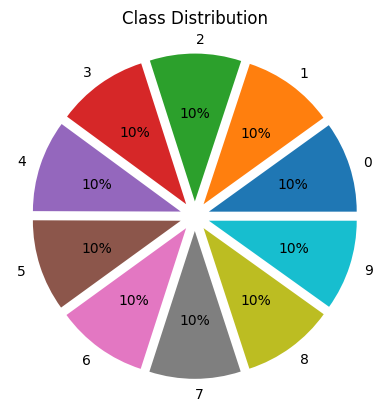

In [6]:
x = list(dist.values())
labels = list(dist.keys())
explode = [0.1 for _ in labels]

plt.pie(x, labels=labels, explode=explode, autopct='%.f%%')
plt.title('Class Distribution')
plt.show()

## Train/Test Split (80/20)

In [7]:
def create_train_test_split(dataset_path, classes, train_perc=0.8):
    train_path = Path('./Data/train')
    test_path = Path('./Data/test')

    if Path('./Data').exists():
        shutil.rmtree('./Data')

    train_path.mkdir(parents=True, exist_ok=True)
    test_path.mkdir(parents=True, exist_ok=True)

    for class_name in classes:
        (train_path / class_name).mkdir(parents=True, exist_ok=True)
        (test_path / class_name).mkdir(parents=True, exist_ok=True)

        images = os.listdir(Path(dataset_path) / class_name)
        images.sort()
        train_len = int(train_perc * len(images))

        for image in images[:train_len]:
            shutil.copy(Path(dataset_path) / class_name / image, train_path / class_name)

        for image in images[train_len:]:
            shutil.copy(Path(dataset_path) / class_name / image, test_path / class_name)

    print('Done')
    return train_path.resolve(), test_path.resolve()


train_path, test_path = create_train_test_split(data_path, classes, train_perc=0.8)
train_path, test_path

Done


(WindowsPath('C:/Users/HP/Desktop/Bacancy/AI_ML/Deep_Learning/NLP/Deep-Learning-Practicals/CNN/PyTorch/Data/train'),
 WindowsPath('C:/Users/HP/Desktop/Bacancy/AI_ML/Deep_Learning/NLP/Deep-Learning-Practicals/CNN/PyTorch/Data/test'))

In [8]:
get_dataset_detail(train_path)
get_dataset_detail(test_path)

Number Of Classes 10
Number Of Classes 10


['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

In [9]:
get_distribution_of_images(train_path, classes), get_distribution_of_images(test_path, classes)

({'0': 164,
  '1': 164,
  '2': 164,
  '3': 164,
  '4': 165,
  '5': 165,
  '6': 165,
  '7': 164,
  '8': 166,
  '9': 163},
 {'0': 41,
  '1': 42,
  '2': 42,
  '3': 42,
  '4': 42,
  '5': 42,
  '6': 42,
  '7': 42,
  '8': 42,
  '9': 41})

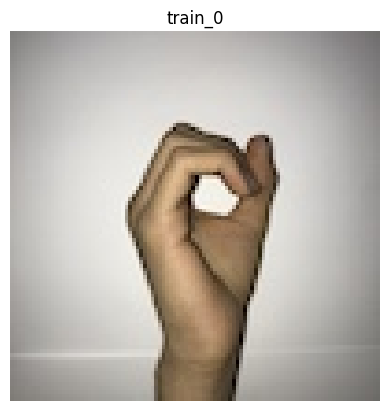

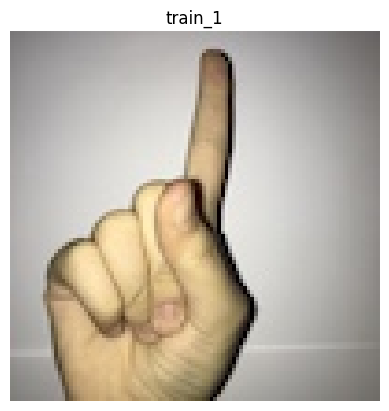

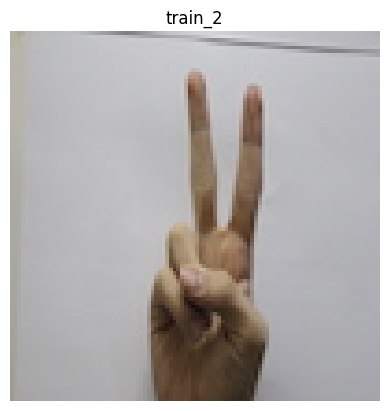

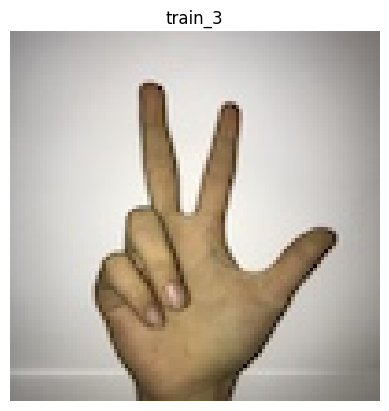

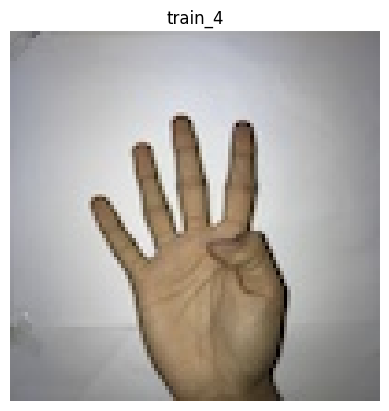

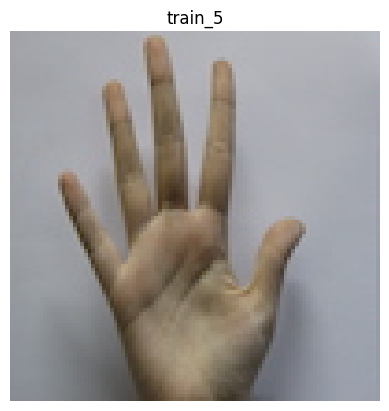

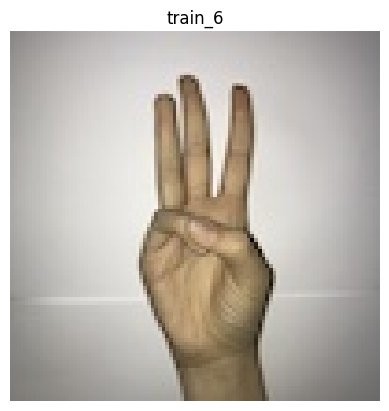

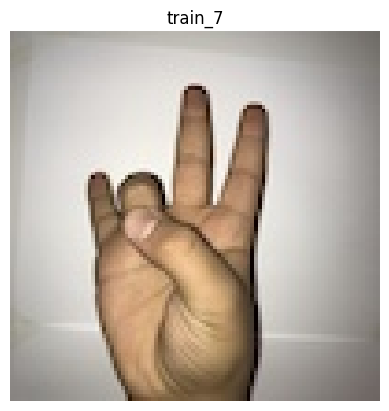

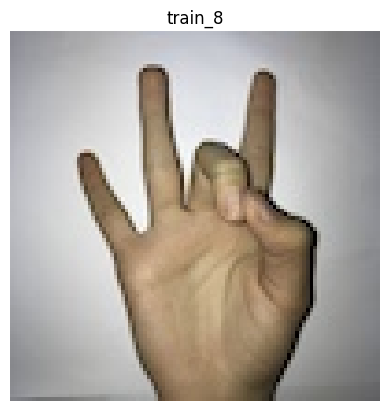

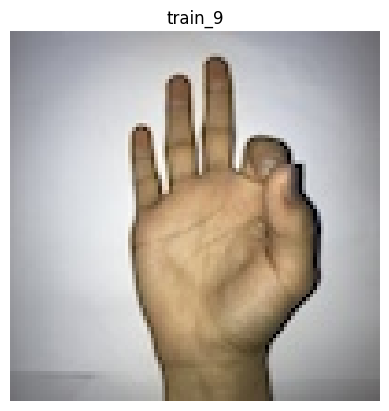

In [10]:
def see_random_data(path, classes, train=True):
    for class_name in classes:
        random_image = np.random.choice(os.listdir(Path(path) / class_name))
        plt.imshow(plt.imread(Path(path) / class_name / random_image))
        plt.title(f"{'train' if train else 'test'}_{class_name}")
        plt.axis('off')
        plt.show()


see_random_data(train_path, classes, train=True)

## DataLoaders

In [11]:
batch_size = 32
image_size = (224, 224)

train_transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(root=str(train_path), transform=train_transform)
test_dataset = datasets.ImageFolder(root=str(test_path), transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

class_names = train_dataset.classes
class_names

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

In [12]:
y_label = [label for _, label in test_dataset.samples]
y_label[:10]

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

## Evaluation Utilities

In [13]:
def model_evaluation(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )
    metrics = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
    }
    return metrics


def plot_loss_curve(history):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, history['train_loss'], label='training_loss')
    plt.plot(epochs, history['val_loss'], label='val_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, history['train_acc'], label='training_accuracy')
    plt.plot(epochs, history['val_acc'], label='val_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

## Model 1

In [14]:
class SignLanguageCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),
            nn.BatchNorm2d(64),

            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),
            nn.BatchNorm2d(32),

            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),
            nn.BatchNorm2d(16),

            nn.Conv2d(16, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),
            nn.BatchNorm2d(8),

            nn.AdaptiveAvgPool2d((4, 4)),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(8 * 4 * 4, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = SignLanguageCNN(num_classes=len(class_names)).to(device)
model

SignLanguageCNN(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout(p=0.25, inplace=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Dropout(p=0.25, inplace=False)
    (9): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (13): Dropout(p=0.25, inplace=False)
    (14): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (15): Conv2d(16, 8, kernel_size=(3, 3

In [15]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=100, patience=30, model_name='model_1'):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_weights = copy.deepcopy(model.state_dict())
    patience_counter = 0

    model_path = Path('./Models') / f'{model_name}.pth'
    model_path.parent.mkdir(parents=True, exist_ok=True)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        running_correct = 0
        running_total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            running_correct += (preds == labels).sum().item()
            running_total += labels.size(0)

        train_loss = running_loss / running_total
        train_acc = running_correct / running_total

        model.eval()
        val_loss_sum = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss_sum += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_loss_sum / val_total
        val_acc = val_correct / val_total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(
            f"Epoch {epoch + 1}/{epochs} | train_loss: {train_loss:.4f} | "
            f"val_loss: {val_loss:.4f} | train_acc: {train_acc:.4f} | val_acc: {val_acc:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(
                {
                    'model_state_dict': best_weights,
                    'class_names': class_names,
                    'best_val_loss': best_val_loss,
                },
                model_path,
            )
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch + 1}')
            break

    model.load_state_dict(best_weights)
    return model, history, str(model_path)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model, history, best_model_path = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=100,
    patience=30,
    model_name='sign_lan_digit_model'
)
best_model_path

In [ ]:
plot_loss_curve(history)

In [ ]:
model.eval()
y_pred = []

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        y_pred.extend(preds.cpu().numpy())

matrix_dict = model_evaluation(y_label, y_pred)
matrix_dict

In [ ]:
df_metrics = pd.DataFrame([matrix_dict])
df_metrics

In [ ]:
cm = confusion_matrix(y_label, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    cmap='BuPu',
    linewidths=1,
    annot=True,
    fmt='d',
    xticklabels=[i for i in range(10)],
    yticklabels=[i for i in range(10)],
)
plt.title('CM of Model 1')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
checkpoint = torch.load(best_model_path, map_location=device)
model_loaded = SignLanguageCNN(num_classes=len(checkpoint['class_names'])).to(device)
model_loaded.load_state_dict(checkpoint['model_state_dict'])
model_loaded.eval()

y_pred_loaded = []
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        outputs = model_loaded(images)
        preds = torch.argmax(outputs, dim=1)
        y_pred_loaded.extend(preds.cpu().numpy())

matrix_dict_loaded = model_evaluation(y_label, y_pred_loaded)
matrix_dict_loaded

## Model 2 (More Layers)

In [ ]:
class SignLanguageCNN2(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.3),
            nn.BatchNorm2d(256),

            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.3),
            nn.BatchNorm2d(128),

            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.3),
            nn.BatchNorm2d(64),

            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.3),
            nn.BatchNorm2d(32),

            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.3),
            nn.BatchNorm2d(16),

            nn.Conv2d(16, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.3),
            nn.BatchNorm2d(8),

            nn.AdaptiveAvgPool2d((2, 2)),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(8 * 2 * 2, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model2 = SignLanguageCNN2(num_classes=len(class_names)).to(device)
model2

In [ ]:
criterion2 = nn.CrossEntropyLoss()
optimizer2 = optim.Adam(model2.parameters(), lr=0.001)

model2, history2, best_model_path2 = train_model(
    model=model2,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion2,
    optimizer=optimizer2,
    epochs=100,
    patience=30,
    model_name='sign_lan_digit_model_v2'
)
best_model_path2

In [ ]:
plot_loss_curve(history2)

In [ ]:
model2.eval()
y_pred2 = []

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        outputs = model2(images)
        preds = torch.argmax(outputs, dim=1)
        y_pred2.extend(preds.cpu().numpy())

matrix_dict2 = model_evaluation(y_label, y_pred2)
matrix_dict2